# Day 12 — 子图布局与简历级图表

**目标**：从「能画图」→「画出能放进简历的专业图表」

- 台阶1：GridSpec 网格排版（不等分子图）
- 台阶2：专业配色 + 细节精修
- 台阶3：产出一张个股技术分析仪表盘

In [1]:
# ===== 中文字体设置（每个notebook开头跑一次，全局生效）=====
import matplotlib.pyplot as plt
from matplotlib import font_manager

FONT = '/System/Library/Fonts/Hiragino Sans GB.ttc'   # Mac自带黑体
font_manager.fontManager.addfont(FONT)                # 注册字体
plt.rcParams['font.family'] = 'Hiragino Sans GB'      # 全局用它
plt.rcParams['axes.unicode_minus'] = False            # 负号正常显示（否则变方块）

print('✅ 中文字体已设置：', plt.rcParams['font.family'])

✅ 中文字体已设置： ['Hiragino Sans GB']


## 台阶1：GridSpec 骨架练习

先感受「格子怎么切」，纯排版无数据。`gs[行, 列]`，`:` 表示整行/整列。

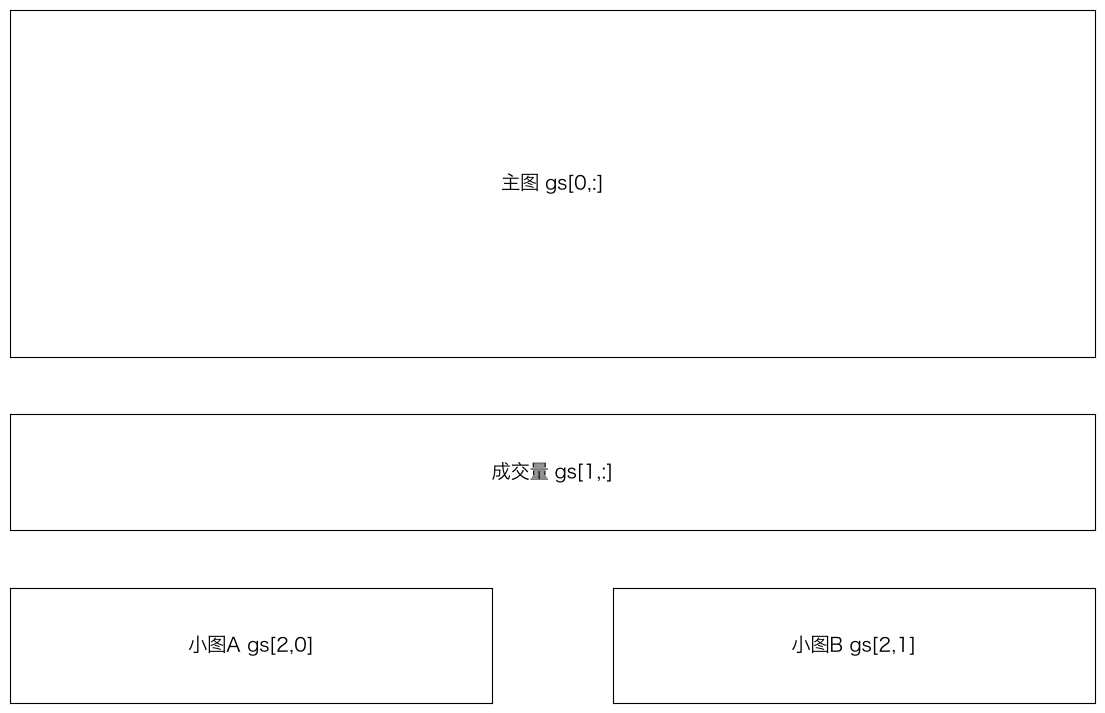

In [3]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 9))
# 3行2列的网格，用 height_ratios 让第一行占大头
gs = GridSpec(3, 2, figure=fig,
              height_ratios=[3, 1, 1],   # 第一行是后两行的3倍高
              hspace=0.3, wspace=0.25)   # 子图间距

ax_main = fig.add_subplot(gs[0, :])   # 第0行，跨所有列 → 主图
ax_vol  = fig.add_subplot(gs[1, :])   # 第1行，跨所有列 → 成交量
ax_a    = fig.add_subplot(gs[2, 0])   # 第2行左 → 小图A
ax_b    = fig.add_subplot(gs[2, 1])   # 第2行右 → 小图B

# 给每个格子写个名字，看清楚布局
for ax, name in [(ax_main, '主图 gs[0,:]'), (ax_vol, '成交量 gs[1,:]'),
                 (ax_a, '小图A gs[2,0]'), (ax_b, '小图B gs[2,1]')]:
    ax.text(0.5, 0.5, name, ha='center', va='center', fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])

plt.show()

## 台阶2+3：茅台技术分析仪表盘（简历级）

把 Day11 学过的均线/成交量/直方图，组装进 GridSpec 布局，再精修细节。
- 主图：收盘价 + MA5/MA20/MA60 均线组
- 成交量：红涨绿跌
- 小图A：日收益率分布
- 小图B：区间累计收益曲线

> 数据源说明：东财在线接口偶发断连，这里改读本地缓存 `data/茅台.csv`。数据层和画图层解耦，换数据源不影响后面的图。

In [4]:
# --- 读本地数据 + 算指标（读缓存csv，不求网络）---
import pandas as pd

df = pd.read_csv('../data/茅台.csv')
df['日期'] = pd.to_datetime(df['日期'])
df = df.set_index('日期').sort_index()

# 均线组
df['MA5']  = df['收盘'].rolling(5).mean()
df['MA20'] = df['收盘'].rolling(20).mean()
df['MA60'] = df['收盘'].rolling(60).mean()
# 日收益率（%）
df['收益率'] = df['收盘'].pct_change() * 100

print('字段:', list(df.columns))
print('行数:', len(df), '| 区间:', df.index[0].date(), '→', df.index[-1].date())
df[['开盘','收盘','成交量','MA5','MA20','收益率']].tail(3)

字段: ['Unnamed: 0', '股票代码', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率', 'MA5', 'MA20', 'MA60', '收益率']
行数: 250 | 区间: 2025-07-01 → 2026-07-10


,开盘,收盘,成交量,MA5,MA20,收益率
日期,,,,,,
2026-07-08,1188.77,1199.30,25776,1198.492,1206.9265,0.883244
2026-07-09,1191.00,1182.19,34096,1194.330,1203.6430,-1.426666
2026-07-10,1182.20,1204.98,52213,1196.436,1201.3430,1.927778


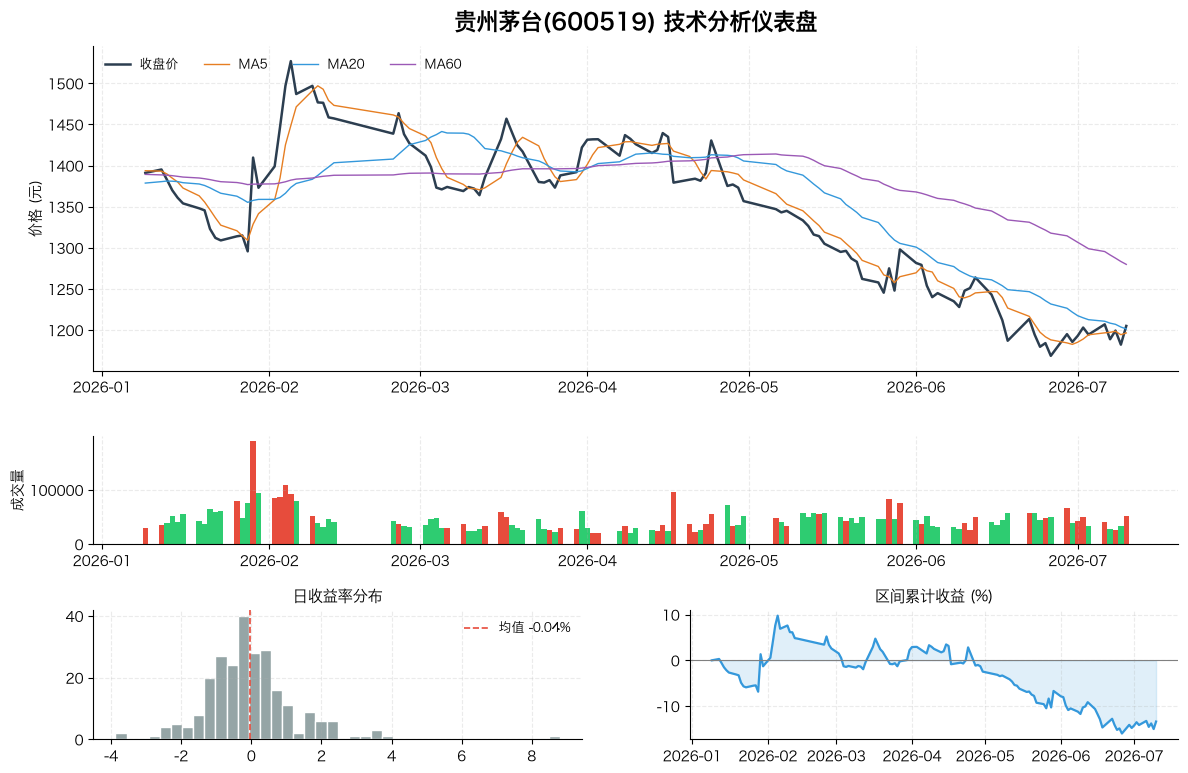

✅ 已保存到 day12/茅台仪表盘.png


In [6]:
# --- 画简历级仪表盘 ---
import numpy as np

d = df.iloc[-120:]   # 只画近120个交易日，太密看不清

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(3, 2, figure=fig, height_ratios=[3, 1, 1.2],
              hspace=0.35, wspace=0.22)

# 配色（克制、专业）
C_PRICE, C_MA5, C_MA20, C_MA60 = '#2c3e50', '#e67e22', '#3498db', '#9b59b6'
C_UP, C_DOWN = '#e74c3c', '#2ecc71'

# ① 主图：价格 + 均线组
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(d.index, d['收盘'], color=C_PRICE, lw=1.8, label='收盘价')
ax1.plot(d.index, d['MA5'],  color=C_MA5,  lw=1.0, label='MA5')
ax1.plot(d.index, d['MA20'], color=C_MA20, lw=1.0, label='MA20')
ax1.plot(d.index, d['MA60'], color=C_MA60, lw=1.0, label='MA60')
ax1.set_title('贵州茅台(600519) 技术分析仪表盘', fontsize=16, fontweight='bold', pad=12)
ax1.legend(loc='upper left', ncol=4, frameon=False, fontsize=9)
ax1.set_ylabel('价格 (元)')

# ② 成交量：红涨绿跌
ax2 = fig.add_subplot(gs[1, :], sharex=ax1)
vol_colors = np.where(d['收盘'] >= d['开盘'], C_UP, C_DOWN)
ax2.bar(d.index, d['成交量'], color=vol_colors, width=1.0)
ax2.set_ylabel('成交量')

# ③ 小图A：收益率分布
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(df['收益率'].dropna(), bins=40, color='#95a5a6', edgecolor='white')
ax3.axvline(df['收益率'].mean(), color=C_UP, ls='--', lw=1.2, label=f"均值 {df['收益率'].mean():.2f}%")
ax3.set_title('日收益率分布', fontsize=11)
ax3.legend(frameon=False, fontsize=9)

# ④ 小图B：近120日累计收益
ax4 = fig.add_subplot(gs[2, 1])
cum = (1 + d['收盘'].pct_change().fillna(0)).cumprod() - 1
ax4.plot(cum.index, cum * 100, color=C_MA20, lw=1.6)
ax4.fill_between(cum.index, cum * 100, 0, alpha=0.15, color=C_MA20)
ax4.axhline(0, color='gray', lw=0.8)
ax4.set_title('区间累计收益 (%)', fontsize=11)

# 统一精修：去顶/右边框 + 淡网格
for ax in [ax1, ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.25, ls='--')

fig.savefig('../day12/茅台仪表盘.png', dpi=150, bbox_inches='tight')  # 存一张给简历
plt.show()
print('✅ 已保存到 day12/茅台仪表盘.png')